# Advanced layer types -- Image Classification

## 0. Import packages and modules

In [1]:
import os

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from tqdm import tqdm

import pathlib

import sklearn
import torch
from torch import nn

from torchinfo import summary
#import torchmetrics

print(sklearn.__version__)
print(torch.__version__)

1.6.1
2.7.1+rocm6.2.4


In [2]:
# print GPU info

print(f"CUDA available: {torch.cuda.is_available()}")

print(f"Num GPUs Available: {torch.cuda.device_count()}")

if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"{torch.cuda.get_device_name(device)}: temp: {torch.cuda.temperature(device)} °C, power draw: {torch.cuda.power_draw()} mW, clock rate: {torch.cuda.clock_rate()} MHz")
else:
    device = torch.device("cpu")

CUDA available: True
Num GPUs Available: 1
AMD Instinct MI250X: temp: 57 °C, power draw: 316 mW, clock rate: 800 MHz


## 1. Formulate / Outline the problem: Image classification

In [3]:
DATA_FOLDER = pathlib.Path(f"/scratch/project_465002387/data/DollarStreet10") # change to location where you stored the data
train_images = np.load(DATA_FOLDER / 'train_images.npy')
val_images = np.load(DATA_FOLDER / 'test_images.npy')
train_labels = np.load(DATA_FOLDER / 'train_labels.npy')
val_labels = np.load(DATA_FOLDER / 'test_labels.npy')

## 2. Identify inputs and outputs

In [4]:
train_images.shape

(878, 64, 64, 3)

In [5]:
train_images.min(), train_images.max()

(0, 255)

In [6]:
train_labels.shape

(878,)

In [7]:
train_labels.min(), train_labels.max()

(0, 9)

## 3. Prepare data

In [8]:
class DollarStreetDataset(torch.utils.data.Dataset):
    def __init__(self, root, train=True):
        prefix = "test"
        if train == True:
            prefix = "train"
        self.images = np.load(root / f'{prefix}_images.npy') / 255.
        self.labels = np.load(root / f'{prefix}_labels.npy')
        
    def __getitem__(self, idx):
        x = torch.permute(torch.tensor(self.images[idx], dtype=torch.float), (2, 0, 1))
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y
        
    def __len__(self):
        return self.images.shape[0]

train_ds = DollarStreetDataset(root=DATA_FOLDER, train=True)
val_ds = DollarStreetDataset(root=DATA_FOLDER, train=False)

## 4. Build a pretrained model

In [9]:
class DollarStreetModelSmall(nn.Module):
    def __init__(self):
        super().__init__()
        self.s = nn.Sequential(
            nn.Conv2d(3, 50, 3),
            nn.ReLU(),
            nn.Conv2d(50, 50, 3),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(50*60*60, 10),
        )
    def forward(self, x):
        return self.s(x)

model = DollarStreetModelSmall()

In [10]:
summary(model, input_size=(1, 3, 64, 64))

Layer (type:depth-idx)                   Output Shape              Param #
DollarStreetModelSmall                   [1, 10]                   --
├─Sequential: 1-1                        [1, 10]                   --
│    └─Conv2d: 2-1                       [1, 50, 62, 62]           1,400
│    └─ReLU: 2-2                         [1, 50, 62, 62]           --
│    └─Conv2d: 2-3                       [1, 50, 60, 60]           22,550
│    └─ReLU: 2-4                         [1, 50, 60, 60]           --
│    └─Flatten: 2-5                      [1, 180000]               --
│    └─Linear: 2-6                       [1, 10]                   1,800,010
Total params: 1,823,960
Trainable params: 1,823,960
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 88.36
Input size (MB): 0.05
Forward/backward pass size (MB): 2.98
Params size (MB): 7.30
Estimated Total Size (MB): 10.32

In [11]:
class DollarStreetModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.s = nn.Sequential(
            nn.Conv2d(3, 50, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(50, 50, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(14*14*50, 50),
            nn.ReLU(),
            nn.Linear(50, 10),
        )
    def forward(self, x):
        return self.s(x)

model = DollarStreetModel()
summary(model, input_size=(1, 3, 64, 64))

Layer (type:depth-idx)                   Output Shape              Param #
DollarStreetModel                        [1, 10]                   --
├─Sequential: 1-1                        [1, 10]                   --
│    └─Conv2d: 2-1                       [1, 50, 62, 62]           1,400
│    └─ReLU: 2-2                         [1, 50, 62, 62]           --
│    └─MaxPool2d: 2-3                    [1, 50, 31, 31]           --
│    └─Conv2d: 2-4                       [1, 50, 29, 29]           22,550
│    └─ReLU: 2-5                         [1, 50, 29, 29]           --
│    └─MaxPool2d: 2-6                    [1, 50, 14, 14]           --
│    └─Flatten: 2-7                      [1, 9800]                 --
│    └─Linear: 2-8                       [1, 50]                   490,050
│    └─ReLU: 2-9                         [1, 50]                   --
│    └─Linear: 2-10                      [1, 10]                   510
Total params: 514,510
Trainable params: 514,510
Non-trainable params: 0


## 5. Choose a loss function and optimizer

In [12]:
optim = torch.optim.Adam
loss_fn = torch.nn.CrossEntropyLoss

## 6. Train the model

In [13]:
def train(dl, model, loss_fn, optimizer, device=torch.device("cuda:0")):
    model = model.to(device)
    model.train()

    avg_loss = 0.0
    avg_acc = 0.0
    
    for step, (x, y) in enumerate(tqdm(dl)):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        pred = model(x)
        loss_val = loss_fn(pred, y)
        loss_val.backward()
        optimizer.step()

        avg_loss += loss_val.item()
        avg_acc += (pred.argmax(1) == y).sum().item()
    avg_loss /= len(dl)
    avg_acc /= len(dl.dataset)
        
    return avg_loss, avg_acc

def test(dl, model, loss_fn, device=torch.device("cuda:0")):
    model = model.to(device)
    model.eval()
    
    avg_loss = 0.0
    avg_acc = 0.0
    with torch.no_grad():
        for step, (x, y) in enumerate(dl):
            x, y = x.to(device), y.to(device)
            pred = model(x)
            avg_loss += loss_fn(pred, y).item()
            avg_acc += (pred.argmax(1) == y).type(torch.float).sum().item()
    avg_loss /= len(dl)
    avg_acc /= (len(dl.dataset))
    print(f"Test accuracy: {(100 * avg_acc):>0.1f}%, Avg loss: {avg_loss:>8f}")
    return avg_loss, avg_acc

def fit(model, optimizer, loss, train_ds, val_ds, batch_size=32, learning_rate=0.001, num_epochs=20):

    # instantiate optimizer and loss_fn
    loss_fn = loss()
    optim = optimizer(model.parameters(), lr=learning_rate)

    train_dl = torch.utils.data.DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_dl = torch.utils.data.DataLoader(val_ds, batch_size=1, shuffle=False)

    history = {"loss": [], "val_loss": [], "accuracy": [], "val_accuracy": []}
    for epoch in range(num_epochs):
        train_loss, train_acc = train(train_dl, model, loss_fn, optim, device=device)
        val_loss, val_acc = test(val_dl, model, loss_fn, device=device)

        for k, v in [("loss", train_loss), ("val_loss", val_loss), ("accuracy", train_acc), ("val_accuracy", val_acc)]:
            history[k].append(v)
    
    return history

In [14]:
history = fit(model, optim, loss_fn, train_ds, val_ds, learning_rate=0.0001)

100%|██████████| 28/28 [00:01<00:00, 16.76it/s]


Test accuracy: 12.6%, Avg loss: 2.294073


100%|██████████| 28/28 [00:00<00:00, 351.09it/s]


Test accuracy: 16.4%, Avg loss: 2.288297


100%|██████████| 28/28 [00:00<00:00, 359.88it/s]


...

Test accuracy: 21.5%, Avg loss: 2.118139


100%|██████████| 28/28 [00:00<00:00, 361.65it/s]


Test accuracy: 26.3%, Avg loss: 2.113117


100%|██████████| 28/28 [00:00<00:00, 353.55it/s]


Test accuracy: 24.2%, Avg loss: 2.099086


## 7. Perform a Prediction/Classification

## 8. Measure performance

In [15]:
def plot_history(history, metrics):
    """
    Plot the training history

    Args:
        history(dict): dictionary containing metrics over the course of training
        metrics(str, list): Metric or a list of metrics to plot
    """
    history_df = pd.DataFrame.from_dict(history)
    sns.lineplot(data=history_df[metrics])
    plt.xlabel("epochs")
    plt.ylabel("metric")


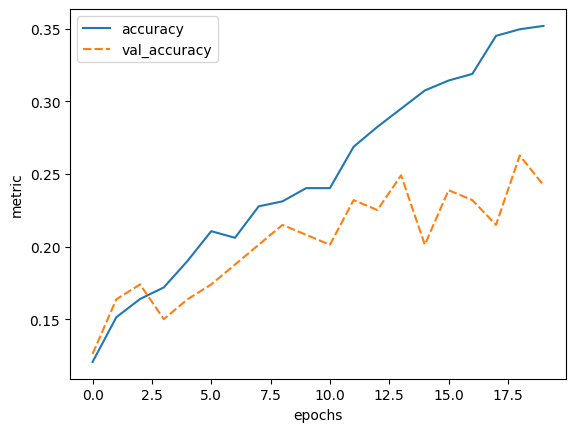

In [16]:
plot_history(history, ['accuracy', 'val_accuracy'])

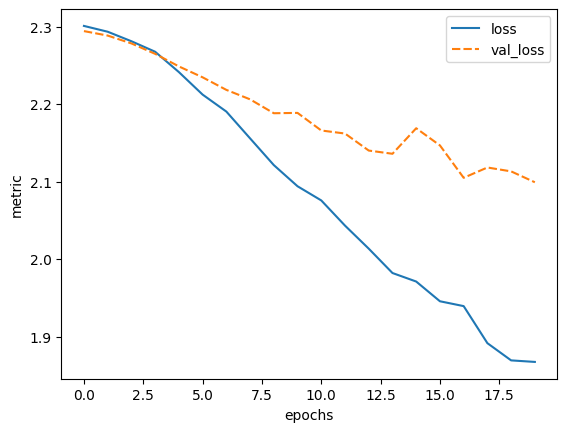

In [17]:
plot_history(history, ['loss', 'val_loss'])

**Comparison with a network with only dense layers**

In [18]:
class DenseModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.s = nn.Sequential(
            nn.Flatten(),
            nn.Linear(12288, 50),
            nn.ReLU(),
            nn.Linear(50, 50),
            nn.ReLU(),
            nn.Linear(50, 10),
        )
    def forward(self, x):
        return self.s(x)

dense_model = DenseModel()
summary(dense_model, input_size=(1, 3, 64, 64))

Layer (type:depth-idx)                   Output Shape              Param #
DenseModel                               [1, 10]                   --
├─Sequential: 1-1                        [1, 10]                   --
│    └─Flatten: 2-1                      [1, 12288]                --
│    └─Linear: 2-2                       [1, 50]                   614,450
│    └─ReLU: 2-3                         [1, 50]                   --
│    └─Linear: 2-4                       [1, 50]                   2,550
│    └─ReLU: 2-5                         [1, 50]                   --
│    └─Linear: 2-6                       [1, 10]                   510
Total params: 617,510
Trainable params: 617,510
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.62
Input size (MB): 0.05
Forward/backward pass size (MB): 0.00
Params size (MB): 2.47
Estimated Total Size (MB): 2.52

In [19]:
dense_history = fit(dense_model, optim, loss_fn, train_ds, val_ds, learning_rate=0.0001)

100%|██████████| 28/28 [00:00<00:00, 435.07it/s]


Test accuracy: 13.0%, Avg loss: 2.297575


100%|██████████| 28/28 [00:00<00:00, 458.25it/s]


Test accuracy: 14.3%, Avg loss: 2.291569


100%|██████████| 28/28 [00:00<00:00, 459.31it/s]


...

Test accuracy: 18.1%, Avg loss: 2.196485


100%|██████████| 28/28 [00:00<00:00, 465.56it/s]


Test accuracy: 19.8%, Avg loss: 2.193238


100%|██████████| 28/28 [00:00<00:00, 465.24it/s]


Test accuracy: 19.8%, Avg loss: 2.183369


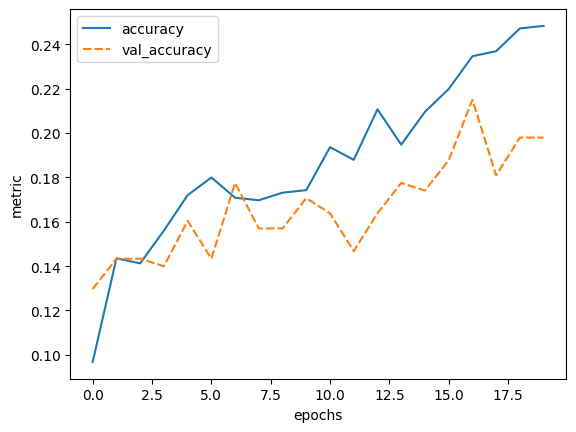

In [20]:
plot_history(dense_history, ['accuracy', 'val_accuracy'])

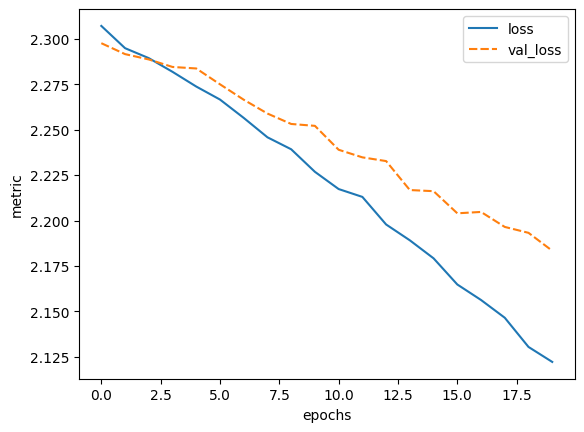

In [21]:
plot_history(dense_history, ['loss', 'val_loss'])

## 9. Refine the model

In [22]:
class ModelDropout(nn.Module):
    def __init__(self):
        super().__init__()
        self.s = nn.Sequential(
            nn.Conv2d(3, 50, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.5),  # This is new!
            nn.Conv2d(50, 50, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.5),  # This is new!
            nn.Conv2d(50, 50, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.5),  # This is new!
            nn.Flatten(),
            nn.Linear(1800, 50),
            nn.ReLU(),
            nn.Linear(50, 10),
        )
    def forward(self, x):
        return self.s(x)

dropout_model = ModelDropout()
summary(dropout_model, input_size=(1, 3, 64, 64))

Layer (type:depth-idx)                   Output Shape              Param #
ModelDropout                             [1, 10]                   --
├─Sequential: 1-1                        [1, 10]                   --
│    └─Conv2d: 2-1                       [1, 50, 62, 62]           1,400
│    └─ReLU: 2-2                         [1, 50, 62, 62]           --
│    └─MaxPool2d: 2-3                    [1, 50, 31, 31]           --
│    └─Dropout: 2-4                      [1, 50, 31, 31]           --
│    └─Conv2d: 2-5                       [1, 50, 29, 29]           22,550
│    └─ReLU: 2-6                         [1, 50, 29, 29]           --
│    └─MaxPool2d: 2-7                    [1, 50, 14, 14]           --
│    └─Dropout: 2-8                      [1, 50, 14, 14]           --
│    └─Conv2d: 2-9                       [1, 50, 12, 12]           22,550
│    └─ReLU: 2-10                        [1, 50, 12, 12]           --
│    └─MaxPool2d: 2-11                   [1, 50, 6, 6]             --
│   

In [23]:
dropout_history = fit(dropout_model, optim, loss_fn, train_ds, val_ds, learning_rate=0.0001)

100%|██████████| 28/28 [00:00<00:00, 265.91it/s]


Test accuracy: 11.3%, Avg loss: 2.303231


100%|██████████| 28/28 [00:00<00:00, 313.75it/s]


Test accuracy: 11.6%, Avg loss: 2.302071


100%|██████████| 28/28 [00:00<00:00, 314.22it/s]


...

Test accuracy: 17.1%, Avg loss: 2.245335


100%|██████████| 28/28 [00:00<00:00, 318.95it/s]


Test accuracy: 17.4%, Avg loss: 2.244081


100%|██████████| 28/28 [00:00<00:00, 317.45it/s]


Test accuracy: 14.3%, Avg loss: 2.241850


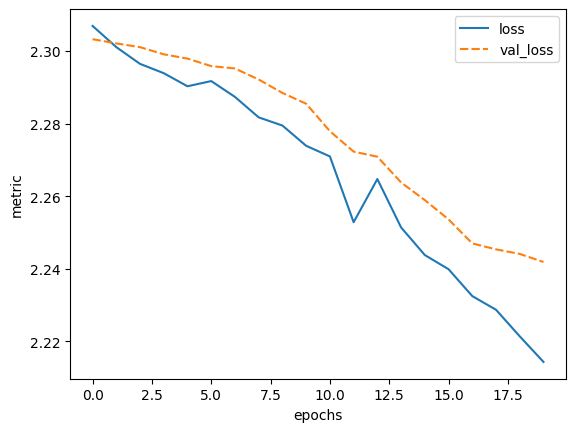

In [24]:
plot_history(dropout_history, ['loss', 'val_loss'])

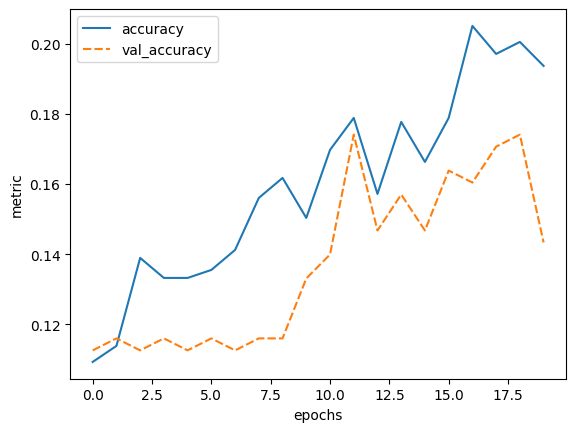

In [25]:
plot_history(dropout_history, ['accuracy', 'val_accuracy'])

In [26]:
class HPModel(nn.Module):
    def __init__(self, dropout_rate, n_layers):
        super().__init__()
        self.in_layer = nn.Sequential(nn.Conv2d(3, 50, 3), nn.ReLU(), nn.MaxPool2d(2))
        self.hidden_layers = nn.Sequential(*[nn.Sequential(nn.Conv2d(50, 50, 3), nn.ReLU(), nn.MaxPool2d(2)) for n in range(n_layers-1)])
        n_features_after_flatten = 64
        for n in range(n_layers):
            n_features_after_flatten = (n_features_after_flatten - 2)//2
        n_features_after_flatten = n_features_after_flatten ** 2 * 50
        self.head = nn.Sequential(nn.Dropout(dropout_rate), nn.Flatten(), nn.Linear(n_features_after_flatten , 50), nn.ReLU(), nn.Linear(50, 10))
    def forward(self, x):
        x = self.in_layer(x)
        x = self.hidden_layers(x)
        x = self.head(x)
        return x

In [27]:
n_layers_grid = [1, 2]
dropout_rate_grid = np.linspace(.2, .8, 3)

best = None
best_loss = float("inf")
best_model = None
histories = {}
trial = 0

for n_layers in n_layers_grid:
    for p in dropout_rate_grid:

        history = fit(HPModel(p, n_layers), optim, loss_fn, train_ds, val_ds, learning_rate=0.0001)
        histories[n_layers, p] = history

        val_loss = min(history["loss"])
        if val_loss < best_loss:
            best_loss = val_loss
            best = (n_layers, p,)
            best_model = model
            
        print(f"trial {trial}: params: {n_layers}, {p}; best: {best_loss} at {best}")
        trial += 1


100%|██████████| 28/28 [00:00<00:00, 377.87it/s]


Test accuracy: 15.0%, Avg loss: 2.273169


100%|██████████| 28/28 [00:00<00:00, 382.13it/s]


Test accuracy: 17.4%, Avg loss: 2.261660


100%|██████████| 28/28 [00:00<00:00, 384.26it/s]


...

Test accuracy: 28.7%, Avg loss: 2.038580


100%|██████████| 28/28 [00:00<00:00, 351.07it/s]


Test accuracy: 30.7%, Avg loss: 2.029536


100%|██████████| 28/28 [00:00<00:00, 353.92it/s]


Test accuracy: 28.0%, Avg loss: 2.043722
trial 5: params: 2, 0.8; best: 1.639475507395608 at (2, 0.5)


In [28]:
print(f"best val loss: {best_loss} at {best}")
print(trial)

best val loss: 1.639475507395608 at (2, 0.5)
6


## 10. Share model

In [29]:
#torch.save(best_model.state_dict(), "image_classifcation.pth")